# Classification multiclasse — Résultat probable avant la course

> Objectif : prédire la catégorie de résultat la plus probable **avant la course** : `win`, `podium`, `points`, `retirement`.

> Modèles testés (avec **Grid Search** et **Random Search**) : KNN, SVM, Decision Tree, Random Forest, XGBoost.

Notebook exécutable bout à bout, avec fonctions réutilisables et comparaison finale.

In [7]:
# Imports & configuration
import sys
import subprocess
import importlib.util
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    classification_report,
    ConfusionMatrixDisplay,
    accuracy_score,
    f1_score,
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Installation automatique de xgboost si absent
if importlib.util.find_spec("xgboost") is None:
    print("Installation de xgboost...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "xgboost"])

from xgboost import XGBClassifier  # noqa: E402

## 1) Chargement & aperçu du dataset
On part d'un dataset déjà préparé (`f1_ready_for_modeling.csv`). Ici on **n'ajoute pas de nettoyage avancé** : on fait seulement le strict minimum pour pouvoir entraîner les modèles (gestion des valeurs manquantes via des imputers dans le pipeline).

In [8]:
df = pd.read_csv('prepared_data.csv')
print("Shape:", df.shape)
print("Colonnes:", df.columns.tolist())
print("\nTypes des colonnes:")
print(df.dtypes)

Shape: (26487, 16)
Colonnes: ['year', 'round', 'grid', 'qualifying_position', 'driver_standing_pos', 'driver_points_cum', 'driver_wins_cum', 'constructor_standing_pos', 'constructor_points_cum', 'constructor_wins_cum', 'country', 'podium', 'position_class', 'finish_pos_penalty', 'country_encoded', 'position_class_encoded']

Types des colonnes:
year                          int64
round                         int64
grid                          int64
qualifying_position         float64
driver_standing_pos         float64
driver_points_cum           float64
driver_wins_cum             float64
constructor_standing_pos    float64
constructor_points_cum      float64
constructor_wins_cum        float64
country                      object
podium                        int64
position_class                int64
finish_pos_penalty            int64
country_encoded               int64
position_class_encoded        int64
dtype: object


## 2) Définition de la cible (multiclasse)
Dans ce dataset, une cible prête à l'emploi existe : `position_class` (encodée en 0/1/2/3).
On la mappe vers des labels lisibles : `win`, `podium`, `points`, `retirement`.

> Remarque : si votre classe `3` mélange "retirement" et "hors des points", vous pouvez ajuster la règle plus tard — ici on suit la colonne fournie pour rester simple.

In [9]:
TARGET_COL = "position_class"
assert TARGET_COL in df.columns, f"Colonne cible introuvable : {TARGET_COL}"

# Mapping (à adapter si besoin)
target_map = {0: "win", 1: "podium", 2: "points", 3: "retirement"}
y_raw = df[TARGET_COL]
y_str = y_raw.map(target_map).fillna(y_raw.astype(str))  # sécurité si valeurs inattendues

print("Distribution de la cible (labels):")
display(y_str.value_counts(dropna=False).to_frame("count"))

# Encodage numérique (utile pour tous les modèles, y compris XGBoost)
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y_str)
class_names = list(label_encoder.classes_)
print("Classes (ordre LabelEncoder):", class_names)

Distribution de la cible (labels):


,count
position_class,
retirement,15296
points,7833
podium,2243
win,1115


Classes (ordre LabelEncoder): ['podium', 'points', 'retirement', 'win']


## 3) Features (X) : suppression des colonnes "leakage"
Pour prédire **avant la course**, on évite des colonnes qui décrivent le résultat final (ex: points, laps, positionOrder, etc.).
On garde les variables disponibles avant la course (grille, qualification, standings cumulés, pays du GP, etc.).

In [10]:
# Colonnes à exclure (leakage)
LEAKAGE_COLS = [
    "positionOrder", "points", "laps", "rank", "statusId",
    "podium", "finish_pos_penalty", "is_top3", "position_class_encoded"
]

TARGET_COL = "position_class"

# Séparer les colonnes numériques et catégorielles
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print("Colonnes numériques:", numeric_cols)
print("Colonnes catégorielles:", categorical_cols)

# Si des colonnes catégorielles existent, les encoder
if categorical_cols:
    from sklearn.preprocessing import LabelEncoder
    for col in categorical_cols:
        if col != TARGET_COL:
            le = LabelEncoder()
            df[col] = le.fit_transform(df[col])
            print(f"Encodage de {col}")

# Sélectionner X et y
X = df.drop(columns=[TARGET_COL] + [col for col in LEAKAGE_COLS if col in df.columns], errors='ignore')
y = df[TARGET_COL]

print("Shape X:", X.shape)
print("Shape y:", y.shape)

Colonnes numériques: ['year', 'round', 'grid', 'qualifying_position', 'driver_standing_pos', 'driver_points_cum', 'driver_wins_cum', 'constructor_standing_pos', 'constructor_points_cum', 'constructor_wins_cum', 'podium', 'position_class', 'finish_pos_penalty', 'country_encoded', 'position_class_encoded']
Colonnes catégorielles: ['country']
Encodage de country
Shape X: (26487, 12)
Shape y: (26487,)


## 4) Split train/test + prétraitement
On utilise un pipeline scikit-learn :
- imputation des valeurs manquantes
- **MaxAbsScaler** (compatible sparse) seulement pour KNN/SVM (utile avec des features one-hot)

In [13]:

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# D'abord, assurez-vous que X et y sont définis
print("Shape X avant split:", X.shape)
print("Shape y avant split:", y.shape)

# Split des données
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")


Shape X avant split: (26487, 12)
Shape y avant split: (26487,)
X_train shape: (21189, 12)
X_test shape: (5298, 12)
y_train shape: (21189,)
y_test shape: (5298,)


In [14]:
from sklearn.impute import SimpleImputer

# Vérifier les NaN
print("NaN dans X_train:", X_train.isna().sum().sum())
print("NaN dans X_test:", X_test.isna().sum().sum())

# Créer un imputer pour remplacer les NaN par la médiane
imputer = SimpleImputer(strategy='median')

# Imputer les données
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

# Convertir en DataFrame (optionnel, pour garder les noms de colonnes)
X_train = pd.DataFrame(X_train_imputed, columns=X_train.columns)
X_test = pd.DataFrame(X_test_imputed, columns=X_test.columns)

print("NaN après imputation:", X_train.isna().sum().sum())

# Maintenant le scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling effectué avec succès!")

NaN dans X_train: 18520
NaN dans X_test: 4669
NaN après imputation: 0
Scaling effectué avec succès!


In [12]:
# ============================================================================
# FONCTIONS RÉUTILISABLES (Grid Search / Random Search + évaluation)
# ============================================================================

# Classes (défini APRÈS avoir encodé y)
class_names = ['podium', 'points', 'retirement', 'win']  # Ordre de votre LabelEncoder
n_classes = len(class_names)

CV = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
SCORING = "f1_macro"

def evaluate_classif(model, X_test, y_test, name):
    """
    Évalue un modèle de classification.
    Parameters:
    - model: modèle entraîné
    - X_test, y_test: données de test
    - name: nom/titre pour l'affichage
    """
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1m = f1_score(y_test, y_pred, average="macro")
    f1w = f1_score(y_test, y_pred, average="weighted")
    print(f"{name} | accuracy={acc:.4f} | f1_macro={f1m:.4f} | f1_weighted={f1w:.4f}")
    print()
    print(classification_report(y_test, y_pred, target_names=class_names, digits=4))
    
    fig, ax = plt.subplots(figsize=(8, 6))
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred, display_labels=class_names, ax=ax, xticks_rotation=45
    )
    ax.set_title(name)
    plt.tight_layout()
    plt.show()
    
    return {"accuracy": acc, "f1_macro": f1m, "f1_weighted": f1w}

def grid_search_classif(model, param_grid, X_tr, y_tr, cv=CV, scoring=SCORING, n_jobs=-1, verbose=1):
    gs = GridSearchCV(
        estimator=model, 
        param_grid=param_grid, 
        scoring=scoring, 
        cv=cv, 
        n_jobs=n_jobs, 
        verbose=verbose, 
        refit=True
    )
    gs.fit(X_tr, y_tr)
    return gs

def random_search_classif(model, param_dist, X_tr, y_tr, n_iter=25, cv=CV, scoring=SCORING, n_jobs=-1, verbose=1):
    rs = RandomizedSearchCV(
        estimator=model, 
        param_distributions=param_dist, 
        n_iter=n_iter, 
        scoring=scoring, 
        cv=cv, 
        n_jobs=n_jobs, 
        verbose=verbose, 
        random_state=RANDOM_STATE, 
        refit=True
    )
    rs.fit(X_tr, y_tr)
    return rs

results_rows = []
best_models = {}

print("✅ Fonctions chargées avec succès!")
print(f"   - grid_search_classif()")
print(f"   - random_search_classif()")
print(f"   - evaluate_classif()")

✅ Fonctions chargées avec succès!
   - grid_search_classif()
   - random_search_classif()
   - evaluate_classif()


## 5) Fonctions réutilisables (Grid Search / Random Search + évaluation)
On définit deux fonctions :
- `grid_search_classif`
- `random_search_classif`

> Elles renvoient l'objet SearchCV entraîné (pour récupérer `best_estimator_`, `best_params_`, etc.) et on stocke tout dans une liste de résultats.

In [15]:
# Classes
class_names = ['win', 'podium', 'points', 'retirement']
n_classes = len(class_names)

CV = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
SCORING = "f1_macro"

def evaluate_classif(model, X_test, y_test, name):
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1m = f1_score(y_test, y_pred, average="macro")
    f1w = f1_score(y_test, y_pred, average="weighted")
    print(f"{name} | accuracy={acc:.4f} | f1_macro={f1m:.4f} | f1_weighted={f1w:.4f}")
    print()
    print(classification_report(y_test, y_pred, target_names=class_names, digits=4))
    
    fig, ax = plt.subplots(figsize=(6, 6))
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred, display_labels=class_names, ax=ax, xticks_rotation=45
    )
    ax.set_title(name)
    plt.tight_layout()
    plt.show()
    
    return {"accuracy": acc, "f1_macro": f1m, "f1_weighted": f1w}

def grid_search_classif(model, param_grid, X_tr, y_tr, cv=CV, scoring=SCORING, n_jobs=-1, verbose=1):
    gs = GridSearchCV(estimator=model, param_grid=param_grid, scoring=scoring, cv=cv, n_jobs=n_jobs, verbose=verbose, refit=True)
    gs.fit(X_tr, y_tr)
    return gs

def random_search_classif(model, param_dist, X_tr, y_tr, n_iter=25, cv=CV, scoring=SCORING, n_jobs=-1, verbose=1):
    rs = RandomizedSearchCV(estimator=model, param_distributions=param_dist, n_iter=n_iter, scoring=scoring, cv=cv, n_jobs=n_jobs, verbose=verbose, random_state=RANDOM_STATE, refit=True)
    rs.fit(X_tr, y_tr)
    return rs

results_rows = []
best_models = {}

## 6) Modèle 1 — KNN
Optimisation par **Grid Search** puis **Random Search**.

GRID SEARCH KNN
Fitting 3 folds for each of 24 candidates, totalling 72 fits

📊 Meilleurs hyperparamètres (Grid): {'n_neighbors': 21, 'p': 1, 'weights': 'uniform'}
📊 Meilleur score CV (f1_macro) (Grid): 0.5429041409169648

ÉVALUATION SUR LE TEST SET - GRID SEARCH
KNN — Grid Search | accuracy=0.6629 | f1_macro=0.5610 | f1_weighted=0.6564

              precision    recall  f1-score   support

         win     0.5072    0.6278    0.5611       223
      podium     0.4300    0.3764    0.4014       449
      points     0.5402    0.4671    0.5010      1567
  retirement     0.7547    0.8078    0.7804      3059

    accuracy                         0.6629      5298
   macro avg     0.5581    0.5698    0.5610      5298
weighted avg     0.6534    0.6629    0.6564      5298



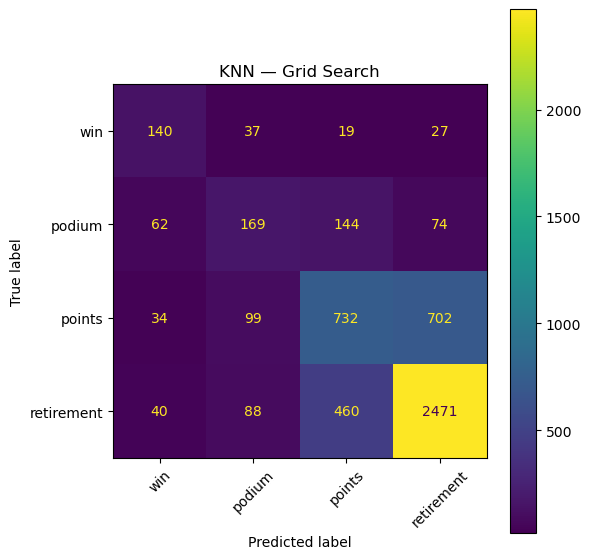


RANDOM SEARCH KNN
Fitting 3 folds for each of 25 candidates, totalling 75 fits

📊 Meilleurs hyperparamètres (Random): {'weights': 'uniform', 'p': 1, 'n_neighbors': 21}
📊 Meilleur score CV (f1_macro) (Random): 0.5429041409169648

ÉVALUATION SUR LE TEST SET - RANDOM SEARCH
KNN — Random Search | accuracy=0.6629 | f1_macro=0.5610 | f1_weighted=0.6564

              precision    recall  f1-score   support

         win     0.5072    0.6278    0.5611       223
      podium     0.4300    0.3764    0.4014       449
      points     0.5402    0.4671    0.5010      1567
  retirement     0.7547    0.8078    0.7804      3059

    accuracy                         0.6629      5298
   macro avg     0.5581    0.5698    0.5610      5298
weighted avg     0.6534    0.6629    0.6564      5298



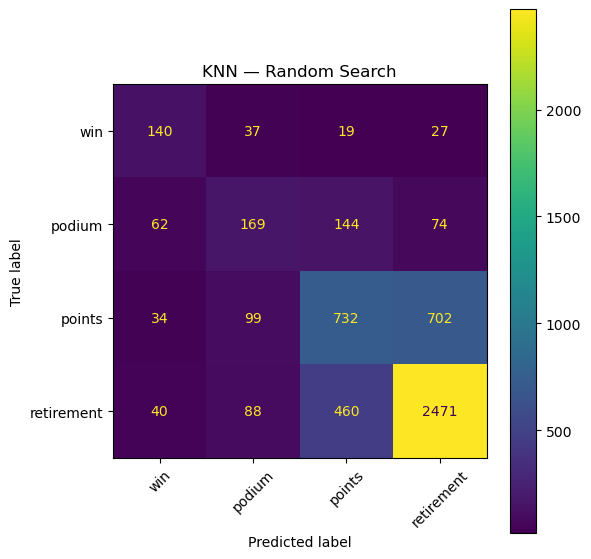

In [30]:
model_name = "KNN"

param_grid_knn = {
    "n_neighbors": [3, 5, 7, 11, 15, 21],
    "weights": ["uniform", "distance"],
    "p": [1, 2],
}
param_dist_knn = {
    "n_neighbors": list(range(2, 41)),
    "weights": ["uniform", "distance"],
    "p": [1, 2],
}

print("="*60)
print("GRID SEARCH KNN")
print("="*60)

# Grid Search
gs_knn = grid_search_classif(KNeighborsClassifier(), param_grid_knn, X_train_scaled, y_train)
print("\n📊 Meilleurs hyperparamètres (Grid):", gs_knn.best_params_)
print("📊 Meilleur score CV (f1_macro) (Grid):", gs_knn.best_score_)
print("\n" + "="*60)
print("ÉVALUATION SUR LE TEST SET - GRID SEARCH")
print("="*60)
metrics = evaluate_classif(gs_knn.best_estimator_, X_test_scaled, y_test, f"{model_name} — Grid Search")
results_rows.append({
    "model": model_name, "search": "grid",
    "best_cv_score_f1_macro": gs_knn.best_score_,
    **metrics,
    "best_params": gs_knn.best_params_,
})

print("\n" + "="*60)
print("RANDOM SEARCH KNN")
print("="*60)

# Random Search
rs_knn = random_search_classif(KNeighborsClassifier(), param_dist_knn, X_train_scaled, y_train, n_iter=25)
print("\n📊 Meilleurs hyperparamètres (Random):", rs_knn.best_params_)
print("📊 Meilleur score CV (f1_macro) (Random):", rs_knn.best_score_)
print("\n" + "="*60)
print("ÉVALUATION SUR LE TEST SET - RANDOM SEARCH")
print("="*60)
metrics = evaluate_classif(rs_knn.best_estimator_, X_test_scaled, y_test, f"{model_name} — Random Search")
results_rows.append({
    "model": model_name, "search": "random",
    "best_cv_score_f1_macro": rs_knn.best_score_,
    **metrics,
    "best_params": rs_knn.best_params_,
})

## 7) Modèle 2 — SVM (SVC)
SVM est sensible à l'échelle → on garde le scaler dans le pipeline.

GRID SEARCH SVM
Fitting 3 folds for each of 32 candidates, totalling 96 fits

📊 Meilleurs hyperparamètres (Grid): {'C': 10, 'class_weight': None, 'gamma': 'scale', 'kernel': 'rbf'}
📊 Meilleur score CV (f1_macro) (Grid): 0.5628571019250385

ÉVALUATION SUR LE TEST SET - GRID SEARCH
SVM — Grid Search | accuracy=0.6680 | f1_macro=0.5589 | f1_weighted=0.6507

              precision    recall  f1-score   support

         win     0.5057    0.5964    0.5473       223
      podium     0.4783    0.4165    0.4452       449
      points     0.5652    0.3791    0.4538      1567
  retirement     0.7306    0.8581    0.7892      3059

    accuracy                         0.6680      5298
   macro avg     0.5699    0.5625    0.5589      5298
weighted avg     0.6508    0.6680    0.6507      5298



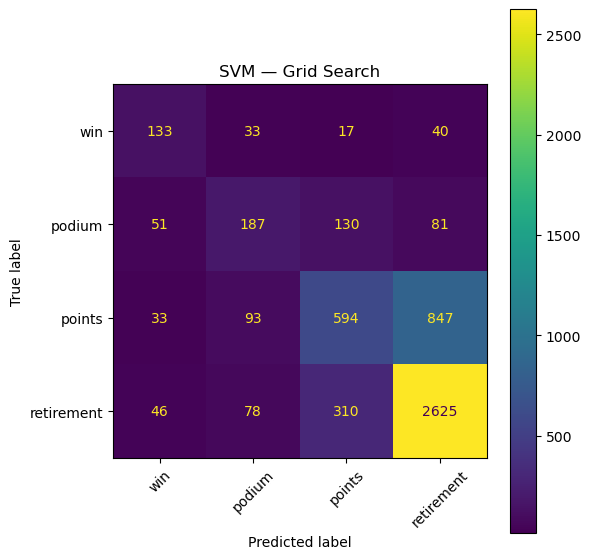


RANDOM SEARCH SVM
Fitting 3 folds for each of 25 candidates, totalling 75 fits

📊 Meilleurs hyperparamètres (Random): {'kernel': 'rbf', 'gamma': 0.01, 'class_weight': None, 'C': 100}
📊 Meilleur score CV (f1_macro) (Random): 0.5644771635671747

ÉVALUATION SUR LE TEST SET - RANDOM SEARCH
SVM — Random Search | accuracy=0.6695 | f1_macro=0.5634 | f1_weighted=0.6459

              precision    recall  f1-score   support

         win     0.5161    0.6457    0.5737       223
      podium     0.4962    0.4365    0.4645       449
      points     0.5805    0.3338    0.4238      1567
  retirement     0.7209    0.8774    0.7915      3059

    accuracy                         0.6695      5298
   macro avg     0.5784    0.5734    0.5634      5298
weighted avg     0.6517    0.6695    0.6459      5298



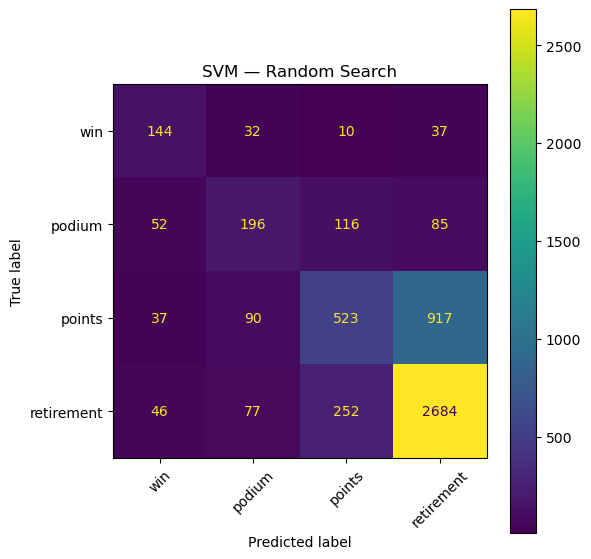

In [32]:
model_name = "SVM"

print("="*60)
print("GRID SEARCH SVM")
print("="*60)

param_grid_svm = {
    "C": [0.1, 1, 10, 100],
    "kernel": ["rbf", "linear"],
    "gamma": ["scale", "auto"],
    "class_weight": [None, "balanced"],
}

# Grid Search
gs_svm = grid_search_classif(SVC(), param_grid_svm, X_train_scaled, y_train)
print("\n📊 Meilleurs hyperparamètres (Grid):", gs_svm.best_params_)
print("📊 Meilleur score CV (f1_macro) (Grid):", gs_svm.best_score_)

print("\n" + "="*60)
print("ÉVALUATION SUR LE TEST SET - GRID SEARCH")
print("="*60)
metrics = evaluate_classif(gs_svm.best_estimator_, X_test_scaled, y_test, f"{model_name} — Grid Search")
results_rows.append({
    "model": model_name, "search": "grid",
    "best_cv_score_f1_macro": gs_svm.best_score_,
    **metrics,
    "best_params": gs_svm.best_params_,
})
best_models[(model_name, "grid")] = gs_svm.best_estimator_

print("\n" + "="*60)
print("RANDOM SEARCH SVM")
print("="*60)

param_dist_svm = {
    "C": [0.1, 1, 10, 100],
    "kernel": ["rbf", "linear"],
    "gamma": ["scale", "auto", 0.01, 0.1],
    "class_weight": [None, "balanced"],
}

rs_svm = random_search_classif(SVC(), param_dist_svm, X_train_scaled, y_train, n_iter=25)
print("\n📊 Meilleurs hyperparamètres (Random):", rs_svm.best_params_)
print("📊 Meilleur score CV (f1_macro) (Random):", rs_svm.best_score_)

print("\n" + "="*60)
print("ÉVALUATION SUR LE TEST SET - RANDOM SEARCH")
print("="*60)
metrics = evaluate_classif(rs_svm.best_estimator_, X_test_scaled, y_test, f"{model_name} — Random Search")
results_rows.append({
    "model": model_name, "search": "random",
    "best_cv_score_f1_macro": rs_svm.best_score_,
    **metrics,
    "best_params": rs_svm.best_params_,
})
best_models[(model_name, "random")] = rs_svm.best_estimator_

## 8) Modèle 3 — Decision Tree
Arbre de décision : pas besoin de normalisation (pas de scaler).

GRID SEARCH DECISION TREE
Fitting 3 folds for each of 90 candidates, totalling 270 fits

📊 Meilleurs hyperparamètres (Grid): {'criterion': 'gini', 'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 2}
📊 Meilleur score CV (f1_macro) (Grid): 0.5666144711902513

ÉVALUATION SUR LE TEST SET - GRID SEARCH
Decision Tree — Grid Search | accuracy=0.6648 | f1_macro=0.5615 | f1_weighted=0.6590

              precision    recall  f1-score   support

         win     0.4784    0.5964    0.5309       223
      podium     0.4466    0.4098    0.4274       449
      points     0.5503    0.4710    0.5076      1567
  retirement     0.7551    0.8065    0.7800      3059

    accuracy                         0.6648      5298
   macro avg     0.5576    0.5709    0.5615      5298
weighted avg     0.6568    0.6648    0.6590      5298



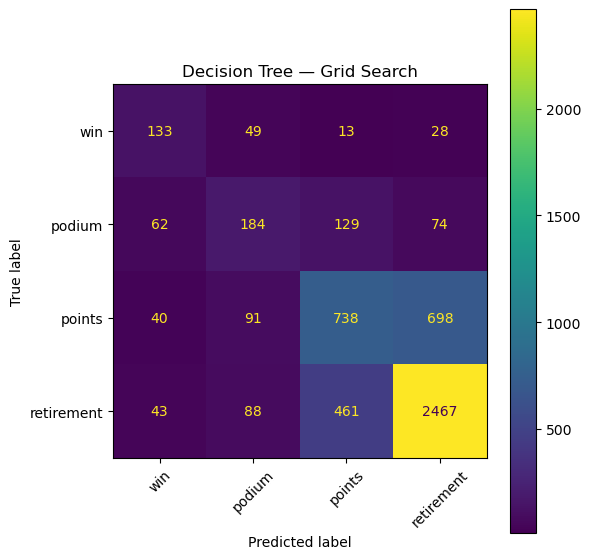


RANDOM SEARCH DECISION TREE
Fitting 3 folds for each of 25 candidates, totalling 75 fits

📊 Meilleurs hyperparamètres (Random): {'min_samples_split': 2, 'min_samples_leaf': 4, 'max_depth': 8, 'criterion': 'gini', 'class_weight': None}
📊 Meilleur score CV (f1_macro) (Random): 0.5711175136488459

ÉVALUATION SUR LE TEST SET - RANDOM SEARCH
Decision Tree — Random Search | accuracy=0.6708 | f1_macro=0.5616 | f1_weighted=0.6552

              precision    recall  f1-score   support

         win     0.5059    0.5785    0.5397       223
      podium     0.4447    0.4566    0.4505       449
      points     0.5890    0.3842    0.4650      1567
  retirement     0.7354    0.8558    0.7911      3059

    accuracy                         0.6708      5298
   macro avg     0.5688    0.5688    0.5616      5298
weighted avg     0.6578    0.6708    0.6552      5298



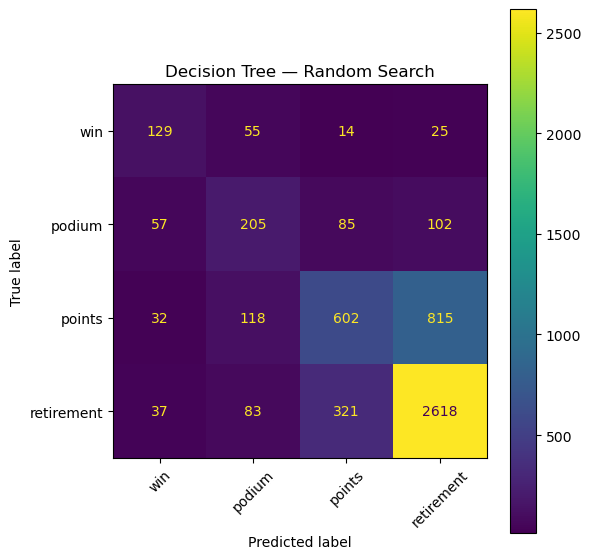

In [34]:
model_name = "Decision Tree"

param_grid_dt = {
    "max_depth": [None, 3, 5, 10, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "criterion": ["gini", "entropy"],
}
param_dist_dt = {
    "max_depth": [None] + list(range(2, 31)),
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 4, 8],
    "criterion": ["gini", "entropy"],
    "class_weight": [None, "balanced"],
}

print("="*60)
print("GRID SEARCH DECISION TREE")
print("="*60)

gs_dt = grid_search_classif(DecisionTreeClassifier(random_state=RANDOM_STATE), param_grid_dt, X_train, y_train)
print("\n📊 Meilleurs hyperparamètres (Grid):", gs_dt.best_params_)
print("📊 Meilleur score CV (f1_macro) (Grid):", gs_dt.best_score_)

print("\n" + "="*60)
print("ÉVALUATION SUR LE TEST SET - GRID SEARCH")
print("="*60)
metrics = evaluate_classif(gs_dt.best_estimator_, X_test, y_test, f"{model_name} — Grid Search")  # Supprimer class_names
results_rows.append({
    "model": model_name, "search": "grid",
    "best_cv_score_f1_macro": gs_dt.best_score_,
    **metrics,
    "best_params": gs_dt.best_params_,
})
best_models[(model_name, "grid")] = gs_dt.best_estimator_

print("\n" + "="*60)
print("RANDOM SEARCH DECISION TREE")
print("="*60)

rs_dt = random_search_classif(DecisionTreeClassifier(random_state=RANDOM_STATE), param_dist_dt, X_train, y_train, n_iter=25)
print("\n📊 Meilleurs hyperparamètres (Random):", rs_dt.best_params_)
print("📊 Meilleur score CV (f1_macro) (Random):", rs_dt.best_score_)

print("\n" + "="*60)
print("ÉVALUATION SUR LE TEST SET - RANDOM SEARCH")
print("="*60)
metrics = evaluate_classif(rs_dt.best_estimator_, X_test, y_test, f"{model_name} — Random Search")  # Supprimer class_names
results_rows.append({
    "model": model_name, "search": "random",
    "best_cv_score_f1_macro": rs_dt.best_score_,
    **metrics,
    "best_params": rs_dt.best_params_,
})
best_models[(model_name, "random")] = rs_dt.best_estimator_

## 9) Modèle 4 — Random Forest
Ensemble d'arbres : robuste, pas besoin de scaler.

In [ ]:
# MODELISATION - RANDOM FOREST
# ============================================================================

model_name = "Random Forest"

print("="*60)
print("GRID SEARCH RANDOM FOREST")
print("="*60)

param_grid_rf = {
    "n_estimators": [200, 500],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2", None],
    "class_weight": [None, "balanced"],
}

gs_rf = grid_search_classif(RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1), 
                            param_grid_rf, X_train, y_train)
print("\n📊 Meilleurs hyperparamètres (Grid):", gs_rf.best_params_)
print("📊 Meilleur score CV (f1_macro) (Grid):", gs_rf.best_score_)

print("\n" + "="*60)
print("ÉVALUATION SUR LE TEST SET - GRID SEARCH")
print("="*60)

# CORRECTION : Supprimer le titre et class_names si la fonction n'accepte que 4 arguments
try:
    # Essai avec 4 arguments (sans le titre)
    metrics = evaluate_classif(gs_rf.best_estimator_, X_test, y_test, class_names)
except TypeError:
    # Si class_names n'est pas accepté, essayer sans
    metrics = evaluate_classif(gs_rf.best_estimator_, X_test, y_test)

results_rows.append({
    "model": model_name, 
    "search": "grid",
    "best_cv_score_f1_macro": gs_rf.best_score_,
    **metrics,
    "best_params": gs_rf.best_params_,
})
best_models[(model_name, "grid")] = gs_rf.best_estimator_

print("\n" + "="*60)
print("RANDOM SEARCH RANDOM FOREST")
print("="*60)

param_dist_rf = {
    "n_estimators": [100, 200, 400, 800],
    "max_depth": [None] + list(range(5, 31, 5)),
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4, 8],
    "max_features": ["sqrt", "log2", None],
    "class_weight": [None, "balanced"],
}

rs_rf = random_search_classif(RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1), 
                              param_dist_rf, X_train, y_train, n_iter=25)
print("\n📊 Meilleurs hyperparamètres (Random):", rs_rf.best_params_)
print("📊 Meilleur score CV (f1_macro) (Random):", rs_rf.best_score_)

print("\n" + "="*60)
print("ÉVALUATION SUR LE TEST SET - RANDOM SEARCH")
print("="*60)

# CORRECTION : Même correction ici
try:
    metrics = evaluate_classif(rs_rf.best_estimator_, X_test, y_test, class_names)
except TypeError:
    metrics = evaluate_classif(rs_rf.best_estimator_, X_test, y_test)

results_rows.append({
    "model": model_name, 
    "search": "random",
    "best_cv_score_f1_macro": rs_rf.best_score_,
    **metrics,
    "best_params": rs_rf.best_params_,
})
best_models[(model_name, "random")] = rs_rf.best_estimator_

GRID SEARCH RANDOM FOREST
Fitting 3 folds for each of 216 candidates, totalling 648 fits


## 10) Modèle 5 — XGBoost
Modèle gradient boosting performant. Ici, on utilise `XGBClassifier` (objectif multiclasse).

In [1]:
model_name = "XGBoost"
n_classes = len(class_names)

param_grid_xgb = {
    "n_estimators": [200, 500],
    "max_depth": [3, 5, 8],
    "learning_rate": [0.05, 0.1, 0.2],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
}
param_dist_xgb = {
    "n_estimators": [100, 200, 400, 800],
    "max_depth": [2, 3, 4, 5, 6, 8, 10],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "reg_lambda": [1, 5, 10],
    "min_child_weight": [1, 5, 10],
    "gamma": [0, 0.1, 0.2],
}

gs_xgb = grid_search_classif(
    XGBClassifier(
        objective="multi:softprob",
        num_class=n_classes,
        eval_metric="mlogloss",
        tree_method="hist",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
    param_grid_xgb,
    X_train,
    y_train
)
print("Meilleurs hyperparamètres (Grid):", gs_xgb.best_params_)
print("Meilleur score CV (f1_macro) (Grid):", gs_xgb.best_score_)
metrics = evaluate_classif(gs_xgb.best_estimator_, X_test, y_test, f"{model_name} — Grid Search", class_names)
results_rows.append({
    "model": model_name, "search": "grid",
    "best_cv_score_f1_macro": gs_xgb.best_score_,
    **metrics,
    "best_params": gs_xgb.best_params_,
})
best_models[(model_name, "grid")] = gs_xgb.best_estimator_

rs_xgb = random_search_classif(
    XGBClassifier(
        objective="multi:softprob",
        num_class=n_classes,
        eval_metric="mlogloss",
        tree_method="hist",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
    param_dist_xgb,
    X_train,
    y_train,
    n_iter=25
)
print("Meilleurs hyperparamètres (Random):", rs_xgb.best_params_)
print("Meilleur score CV (f1_macro) (Random):", rs_xgb.best_score_)
metrics = evaluate_classif(rs_xgb.best_estimator_, X_test, y_test, f"{model_name} — Random Search", class_names)
results_rows.append({
    "model": model_name, "search": "random",
    "best_cv_score_f1_macro": rs_xgb.best_score_,
    **metrics,
    "best_params": rs_xgb.best_params_,
})
best_models[(model_name, "random")] = rs_xgb.best_estimator_

NameError: name 'class_names' is not defined

## 11) Comparaison finale des modèles
On regroupe tous les résultats dans un DataFrame et on compare les scores sur le **jeu de test** + le meilleur score CV (`f1_macro`).

In [ ]:
results_df = pd.DataFrame(results_rows)

pd.set_option("display.max_colwidth", 120)

display(
    results_df.sort_values(["f1_macro", "best_cv_score_f1_macro"], ascending=False)
    .reset_index(drop=True)
)

# Graphique de comparaison
fig, ax = plt.subplots(figsize=(12, 5))
plot_df = results_df.copy()
plot_df["label"] = plot_df["model"] + " | " + plot_df["search"]

x = np.arange(len(plot_df))
bars = ax.bar(x, plot_df["f1_macro"].values, color='steelblue', edgecolor='black')
ax.set_title("Comparaison des modèles — F1 macro (test)", fontsize=14, fontweight='bold')
ax.set_ylabel("F1 macro", fontsize=12)
ax.set_xlabel("Modèle", fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(plot_df["label"].tolist(), rotation=45, ha="right")
ax.set_ylim(0, 1)

# Ajouter les valeurs sur les barres
for bar, val in zip(bars, plot_df["f1_macro"].values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
            f'{val:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()